# Human-in-the-loop

에이전트는 신뢰할 수 없으며 작업을 성공적으로 수행하기 위해 인간의 입력이 필요할 수 있습니다. 

마찬가지로, 일부 작업에 대해서는 모든 것이 의도한 대로 실행되고 있는지 확인하기 위해 실행 전에 **사람이 직접 개입하여 "승인"** 을 요구하고 싶을 수 있습니다.

LangGraph는 여러 가지 방법으로 `human-in-the-loop` 워크플로를 지원합니다. 

이번 튜토리얼의 시작은 LangGraph의 `interrupt_before` 기능을 사용하여 항상 도구 노드를 중단하도록 하겠습니다.

In [1]:
from feature.HummanIntheLoopInterruptBeforeCompileGraph import HumanIntheLoopInterruptBeforeCompileGraph

workflow = HumanIntheLoopInterruptBeforeCompileGraph()

## 그래프 컴파일 (interrupt_before 설정)

이제 그래프를 컴파일합니다. `compile()` 메서드의 `interrupt_before` 파라미터에 `["tools"]`를 전달하면, `tools` 노드가 실행되기 전에 그래프 실행이 중단됩니다. 이를 통해 사람이 도구 호출을 검토하고 승인할 수 있는 기회를 제공합니다.

또한 `checkpointer`를 설정하여 중단된 상태를 저장하고, 나중에 이어서 실행할 수 있게 합니다.

> 참고 문서: [LangGraph Interrupts](https://langchain-ai.github.io/langgraph/concepts/interrupts/)

아래 코드에서는 `interrupt_before`와 체크포인터를 설정하여 그래프를 컴파일합니다.

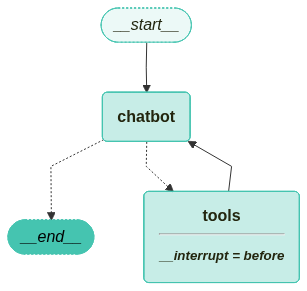

In [2]:
workflow.show_graph()

## 그래프 실행 및 Interrupt 테스트

이제 그래프를 실행하여 `interrupt_before` 설정이 제대로 작동하는지 확인해 봅니다. 

도구 호출이 필요한 질문을 입력하면, `tools` 노드 실행 전에 그래프가 중단되는 것을 확인할 수 있습니다.

In [5]:
from langchain_teddynote.messages import pretty_print_messages
from langchain_core.runnables import RunnableConfig

# 질문
question = "AI 관련 최신 뉴스를 알려주세요."

# 초기 입력 State 를 정의
input = {"messages": [("user", question)]}

# config 설정
config = RunnableConfig(
    recursion_limit=10,  # 최대 10개의 노드까지 방문. 그 이상은 RecursionError 발생
    configurable={"thread_id": "1"},  # 스레드 ID 설정
    tags=["my-rag"],  # Tag
)

for event in workflow.graph.stream(
    input=input,
    config=config,
    stream_mode="values",
):
    for key, value in event.items():
        # key 는 노드 이름
        print(f"\n[{key}]\n")

        # value 는 노드의 출력값
        # print(value)
        pretty_print_messages(value)

        # value 에는 state 가 dict 형태로 저장(values 의 key 값)
        if "messages" in key:
            print(f"메시지 개수: {len(value)}")


[messages]

================================ Human Message =================================

AI 관련 최신 뉴스를 알려주세요.
메시지 개수: 1

[messages]

================================ Human Message =================================

AI 관련 최신 뉴스를 알려주세요.
================================== Ai Message ==================================
Tool Calls:
  search_keyword (call_5EjLNZFF2agH2yWaO2nORIIa)
 Call ID: call_5EjLNZFF2agH2yWaO2nORIIa
  Args:
    query: AI
메시지 개수: 2


## 그래프 상태 확인

그래프 상태를 확인하여 `interrupt_before` 설정이 제대로 작동했는지 확인해 봅니다. `get_state()` 메서드를 통해 현재 스냅샷을 가져오고, `next` 속성을 확인하면 다음에 실행될 노드를 알 수 있습니다.

아래 코드에서는 스냅샷의 `next` 속성을 출력합니다.

In [6]:
# 그래프 상태 스냅샷 생성
snapshot = workflow.get_snapshot(config)

# 다음 스냅샷 상태
snapshot.next

('tools',)

이전 튜토리얼에서는 `__END__`에 도달했기 때문에 `.next`가 존재하지 않았습니다.

하지만 지금은 `.next`가 `('tools',)`로 지정되어 있습니다. 이는 `interrupt_before=["tools"]` 설정으로 인해 `tools` 노드 실행 전에 그래프가 중단되었음을 의미합니다.

다음으로 도구 호출 정보를 확인해 봅시다.

In [7]:
from util.messages import display_message_tree

# 메시지 스냅샷에서 마지막 메시지 추출 (graphState)
existing_message = snapshot.values["messages"][-1]

# 메시지 트리 표시
display_message_tree(existing_message.tool_calls)

    index [0]
        name: "search_keyword"
        args: {"query": "AI"}
        id: "call_5EjLNZFF2agH2yWaO2nORIIa"
        type: "tool_call"


## 그래프 이어서 실행 (Resume)

다음으로는 이전에 종료된 지점 이후부터 **이어서 그래프를 진행**해 봅니다. LangGraph는 중단된 그래프를 쉽게 재개할 수 있는 기능을 제공합니다.

그래프를 이어서 실행하려면 `stream()` 또는 `invoke()` 메서드에 입력값으로 `None`을 전달하면 됩니다. 이렇게 하면 현재 체크포인트 상태에서 이어서 실행됩니다.

아래 코드에서는 `None`을 입력으로 전달하여 그래프를 이어서 실행합니다.

In [8]:
# `None`는 현재 상태에 아무것도 추가하지 않음
events = workflow.graph.stream(None, config, stream_mode="values")

# 이벤트 반복 처리
for event in events:
    # 메시지가 이벤트에 포함된 경우
    if "messages" in event:
        # 마지막 메시지의 예쁜 출력
        event["messages"][-1].pretty_print()

================================== Ai Message ==================================
Tool Calls:
  search_keyword (call_5EjLNZFF2agH2yWaO2nORIIa)
 Call ID: call_5EjLNZFF2agH2yWaO2nORIIa
  Args:
    query: AI
================================= Tool Message =================================
Name: search_keyword

[{"url": "https://news.google.com/rss/articles/CBMigwFBVV95cUxPd3N4S3RON0VTY1QzaWhiZmF6ZUNja21GS3hibDFfR1JXaktWZHVzbEpST3l6ay01bDZFZzZ5amxmZEpfQnhwMlBuRThvRVZsNjdWa05SYWpQMDVINFhLRjhTNVdmRnZMM0U4RkFGQjFPb2p3SlhIandaa3NpS3VzdjlJMA?oc=5", "content": "[단독] AI가 두뇌, 로봇이 손… 사람 없이 24시간 실험 - 조선일보"}, {"url": "https://news.google.com/rss/articles/CBMiVkFVX3lxTFB3ckVnWXNnSXRocU1Gd3d2cUJmczZEanNJcXYwRjhlczY4bnM4cDZfSkF2WDVEVFpjd0hfbUprSk50UkZ4czZWU2YwanFLLXdRTXd4THRB?oc=5", "content": "[단독] 피지컬 AI 속도내는 LG…엔비디아와 전방위 협력 - 매일경제"}, {"url": "https://news.google.com/rss/articles/CBMiVkFVX3lxTFBNZGNNeWNqS3N6MkpQckdSN2hmZmFUSHBRZExMVkw0bEZvbmtjX2w2NGhOZUp4MUVMWDhQeWFVMnJSdDlPS2F2R0h5QzRoRF9WaUtmQW9B?oc=5

## 상태 기록 조회 (State History)

아래는 `get_state_history` 메서드를 사용하여 상태 기록을 가져오는 방법입니다.

상태 기록을 통해 원하는 상태를 지정하여 **해당 지점에서 다시 시작** 할 수 있습니다.

In [9]:
to_replay = None

# 상태 기록 가져오기
for state in workflow.get_state_history(config):
    # 메시지 수 및 다음 상태 출력
    print("메시지 수: ", len(state.values["messages"]), "다음 노드: ", state.next)
    print("-" * 80)
    # 특정 상태 선택 기준: 채팅 메시지 수
    if len(state.values["messages"]) == 3:
        to_replay = state

메시지 수:  4 다음 노드:  ()
--------------------------------------------------------------------------------
메시지 수:  3 다음 노드:  ('chatbot',)
--------------------------------------------------------------------------------
메시지 수:  2 다음 노드:  ('tools',)
--------------------------------------------------------------------------------
메시지 수:  1 다음 노드:  ('chatbot',)
--------------------------------------------------------------------------------
메시지 수:  0 다음 노드:  ('__start__',)
--------------------------------------------------------------------------------


그래프의 모든 단계에 대해 체크포인트가 저장된다는 점에 **주목**할 필요가 있습니다. 이를 통해 특정 시점의 상태로 되돌아가 다시 실행할 수 있습니다.

원하는 지점은 `to_replay` 변수에 저장합니다. 이를 활용하여 특정 시점에서 다시 시작할 수 있습니다.

In [12]:
print(type(workflow.get_snapshot(config)))
print(type(to_replay))


# 다음 항목의 다음 요소 출력
print(to_replay.next)

# 다음 항목의 설정 정보 출력
print(to_replay.config)

<class 'langgraph.types.StateSnapshot'>
<class 'langgraph.types.StateSnapshot'>
('chatbot',)
{'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f1609fd-aca6-6da4-8002-f88209d4a3de'}}


`to_replay.config` 에 `checkpoint_id` 가 포함되어 있습니다.

In [10]:
to_replay.config

{'configurable': {'thread_id': '1',
  'checkpoint_ns': '',
  'checkpoint_id': '1f1607c8-ee7a-6708-8002-477dedf90769'}}

이 `checkpoint_id` 값을 제공하면 LangGraph의 체크포인터가 그 시점의 상태를 **로드** 할 수 있습니다.

- 단, 이때는 입력값을 `None`으로 전달해야 합니다.

아래의 예제를 통해 확인해 봅시다.

In [11]:
# `to_replay.config`는 `checkpoint_id`는 체크포인터에 저장된 상태에 해당
for event in graph.stream(None, to_replay.config, stream_mode="values"):
    # 메시지가 이벤트에 포함된 경우
    if "messages" in event:
        # 마지막 메시지 출력
        event["messages"][-1].pretty_print()

================================= Tool Message =================================
Name: search_keyword

[{"url": "https://news.google.com/rss/articles/CBMiWEFVX3lxTE1tSFhFSDQ3dEFEdGlCd0dPcWRyczN4TnZTd0I1cXAzWlF1WWliWXA3djB6bi1EWjlBVHpNNFZBMTFFeW5ISk80R2hjLUlXWXFmMmZ3ejFsVlc?oc=5", "content": "앤트로픽 \"AI 스스로 후속 모델 개발할 위험…제어장치 필요\" - 뉴스1"}, {"url": "https://news.google.com/rss/articles/CBMiT0FVX3lxTE90QlFlbEkyRUlHMnpWSHZTS0dOSjRfWElYTnF5OC1OUHR2WFBPWTRTdm8telJwalRjRlRSYWpxVTdxLTFCVzNZeXJPOHhDamc?oc=5", "content": "[AI 브리핑] 앤스로픽 \"클로드가 자사 코드 80% 작성\"…AI의 AI 개발 시대 선언 - v.daum.net"}, {"url": "https://news.google.com/rss/articles/CBMidkFVX3lxTE1icmc0Zzd0TEJ0emFQRzlHaUxyVlRpR2hoZ200R3lSVDJxaGxCVTRILXZYNmYyT2Q3Z2NwbnExSlFPNUlJSkhTQ1lnYVlhekFxemRuaGpseXdjUGdhU2FkcGVnQ0I3QW1IZ3VyTkpzRHBFU2p2TXfSAWZBVV95cUxNWU9LcXJ3ZXdmLVg1Z3RNZWkwcHhXaGRwa05iU3ZfOGowUEtIczRTWXVPOFUyVjVBMVdkUDF2VEdmaUZ3UzlVb29vaVh5TU5ycUR6Y1diMVFfZDdYWTh6QU5ibnEwbVE?oc=5", "content": "[단독]앤스로픽 AI 기술 임원, 16일 네이버 본사 찾는다 - 동아일보"}, {"u

## 정리

이번 튜토리얼에서는 `interrupt_before`를 사용하여 human-in-the-loop 워크플로를 구현하는 방법을 알아보았습니다.

**핵심 내용:**
- `compile()` 메서드의 `interrupt_before` 파라미터를 사용하여 특정 노드 실행 전에 그래프를 중단할 수 있습니다.
- `checkpointer`를 설정하면 중단된 상태가 저장되어 나중에 이어서 실행할 수 있습니다.
- `get_state()` 메서드로 현재 상태를 확인하고, `get_state_history()`로 전체 상태 기록을 조회할 수 있습니다.
- 특정 `checkpoint_id`를 지정하여 원하는 시점에서 그래프를 재시작할 수 있습니다.

이를 통해 필요할 때 인간의 감독과 개입을 가능하게 하는 에이전트 시스템을 구축할 수 있습니다.